In [23]:
import pandas as pd

In [24]:
epic = "IX.D.DAX.IFMM.IP"
df = pd.read_csv(f'opening_ranges_2022_{epic}.csv', index_col='utc_time', parse_dates=True)

In [25]:
df

,1min_bid_high,1min_ask_high,1min_bid_low,1min_ask_low,5min_bid_high,5min_ask_high,5min_bid_low,5min_ask_low
utc_time,,,,,,,,
2022-04-26 07:00:00,14121.3,14122.7,14076.8,14078.2,14121.3,14122.7,14067.8,14069.2
2022-04-27 07:00:00,13773.2,13774.6,13740.7,13742.1,13789.7,13791.1,13735.2,13736.6
2022-04-28 07:00:00,13930.4,13931.8,13907.9,13909.3,13930.9,13932.3,13899.4,13900.8
2022-04-29 07:00:00,14102.3,14103.7,14082.8,14084.2,14113.3,14114.7,14069.8,14071.2
2022-05-02 07:00:00,13963.1,13964.5,13939.1,13940.5,13994.1,13995.5,13939.1,13940.5
2022-05-03 07:00:00,14009.9,14011.3,13980.4,13981.8,14009.9,14011.3,13944.9,13946.3
2022-05-04 07:00:00,14036.6,14038.0,14003.6,14005.0,14061.6,14063.0,14003.6,14005.0
2022-05-05 07:00:00,14302.3,14303.7,14275.3,14276.7,14314.8,14316.2,14271.8,14273.2
2022-05-06 07:00:00,13850.2,13851.6,13816.7,13818.1,13851.7,13853.1,13816.7,13818.1


### Distribution 1 Minute Opening Range

<AxesSubplot:ylabel='Frequency'>

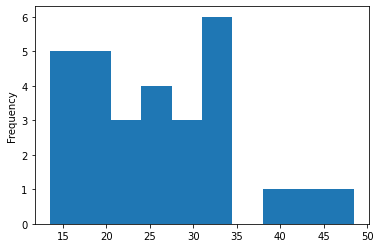

In [26]:
min1 = df['1min_bid_high'] - df['1min_bid_low']
min1.plot.hist()

### Distribution 5 Minute Opening Range

<AxesSubplot:ylabel='Frequency'>

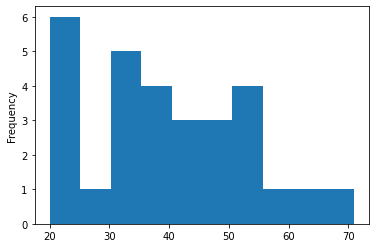

In [27]:
min5 = df['5min_bid_high'] - df['5min_bid_low']
min5.plot.hist()

### Distribution Spread

<AxesSubplot:ylabel='Frequency'>

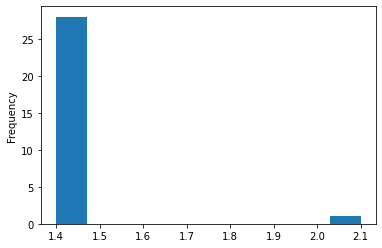

In [28]:
min5 = df['5min_ask_low'] - df['5min_bid_low']
min5.plot.hist()

1/3 5min range inside 1min
- How if my 5min opening range stop is outside reach of 1min range will be better is my theory 

In [31]:
df['5min1R'] = ((df['5min_bid_high'] - df['5min_bid_low']) -1) / 3

In [36]:
df['high_stop_lower'] = (df['5min_bid_high'] - df['5min1R']) < df['1min_bid_high']
df['high_stop_lower'].value_counts()

True     23
False     6
Name: low_stop_higher, dtype: int64

In [37]:
df['low_stop_higher'] = (df['5min_bid_low'] + df['5min1R']) > df['1min_bid_low']
df['low_stop_higher'].value_counts()

True     21
False     8
Name: low_stop_higher, dtype: int64